# Experiment: Featurizer Ablation

Compares **full feature engineering** (`featurizer='full'`) against **minimal as-is encoding** (`featurizer='basic'`) across Logistic Regression and Random Forest.

`sweep()` shares the data load across all runs, and groups featurize by featurizer key so each variant is built only once.

| Featurizer | Description |
|---|---|
| `full`  | ICD grouping, medication direction, engineered interactions (~94 features) |
| `basic` | Raw numerics + ordinal/binary only, no diag codes or medications (~20 features) |

In [1]:
print("Hello")

Hello


In [2]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
    os.system('pip install -q -e .')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import sweep

## Sweep grid

2 featurizers × 2 models = 4 runs. Features are built once per featurizer (2 featurize calls total).

In [4]:
BASE = {
    'wandb_project': 'applied-ai-coursework',
    'split_ratio':   0.8,
}

PARAM_GRID = [
    # --- full features ---
    {
        'name':         'lr_full',
        'featurizer':   'full',
        'model':        'logistic_regression',
        'model_params': {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'},
    },
    {
        'name':         'rf_full',
        'featurizer':   'full',
        'model':        'random_forest',
        'model_params': {'n_estimators': 200, 'max_depth': 10,
                         'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42},
    },
    # --- basic features ---
    {
        'name':         'lr_basic',
        'featurizer':   'basic',
        'model':        'logistic_regression',
        'model_params': {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'},
    },
    {
        'name':         'rf_basic',
        'featurizer':   'basic',
        'model':        'random_forest',
        'model_params': {'n_estimators': 200, 'max_depth': 10,
                         'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42},
    },
]

In [5]:
results = sweep(BASE, PARAM_GRID)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\byamb\_netrc.



[sweep] featurizer=full  subsample=None  (2 configs)
  -> lr_full


wandb: Currently logged in as: byambaa-bayarmandakh-25 (byambaa-bayarmandakh-25-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


e:\UCL-Workspaces\applied-ai-coursework\.conda\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.65362
val_log_loss,0.66893


...

Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-17-37_182d2b_rf_full
  ROC-AUC=0.6296  F1=0.1729  Recall=0.5888  Recall(pos)=0.4128  (3.5s)

[sweep] featurizer=basic  subsample=None  (2 configs)
  -> lr_basic


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.67303
val_log_loss,0.68786


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-17-42_d3452e_lr_basic
  ROC-AUC=0.5787  F1=0.1444  Recall=0.5605  Recall(pos)=0.5027  (2.2s)
  -> rf_basic


train_log_loss,▁
val_log_loss,▁
train_log_loss,0.6024
val_log_loss,0.626


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-07_22-17-44_d4cf7d_rf_basic
  ROC-AUC=0.5716  F1=0.1416  Recall=0.5558  Recall(pos)=0.5080  (5.6s)


## Results

In [6]:

rows = []
for cfg, r in zip(PARAM_GRID, results):
    m = r.metrics
    rows.append({
        'name':        cfg['name'],
        'model':       cfg['model'],
        'featurizer':  cfg['featurizer'],
        'n_features':  r.feature_bundle.n_features,
        'ROC-AUC':     round(m['roc_auc'], 4),
        'F1':          round(m['f1'], 4),
        'Recall':      round(m['recall'], 4),
        'Recall(pos)': round(m['recall_pos'], 4),
        'Precision':   round(m['precision'], 4),
        'Time(s)':     round(r.elapsed_s, 1),
    })

df = pd.DataFrame(rows).set_index('name')
df


,model,featurizer,n_features,ROC-AUC,F1,Recall,Recall(<30),Precision,Time(s)
name,,,,,,,,,
lr_full,logistic_regression,full,94,0.6192,0.1717,0.5812,0.3615,0.1126,13.9
rf_full,random_forest,full,94,0.6296,0.1729,0.5888,0.4128,0.1093,3.5
lr_basic,logistic_regression,basic,18,0.5787,0.1444,0.5605,0.5027,0.0843,2.2
rf_basic,random_forest,basic,18,0.5716,0.1416,0.5558,0.5080,0.0823,5.6


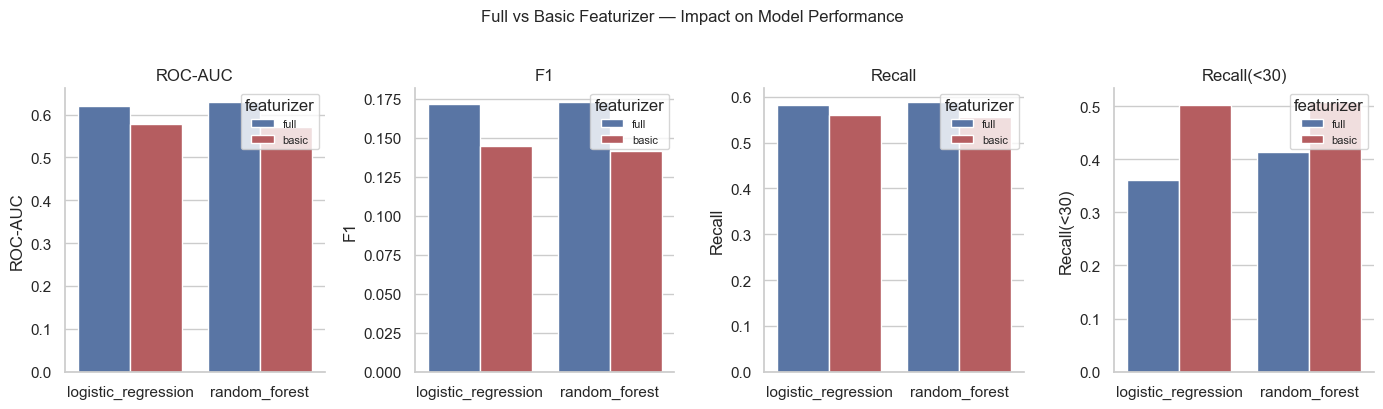

In [10]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, ['ROC-AUC', 'F1', 'Recall', 'Recall(pos)']):
    plot_df = df.reset_index()[['name', 'model', 'featurizer', metric]]
    sns.barplot(
        data=plot_df, x='model', y=metric, hue='featurizer',
        palette={'full': '#4C72B0', 'basic': '#C44E52'}, ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.legend(title='featurizer', fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Full vs Basic Featurizer — Impact on Model Performance', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()